# TASK 4:Loan Default Risk with Business Cost Optimization

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Task 4\credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Dataset Information
df.shape

(32581, 12)

In [4]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
# Handle Missing Values
df.fillna(df.median(numeric_only=True), inplace=True)

df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [9]:
# Encode Categorical Features
le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,123.0,4,3,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4


In [10]:
# Features and Target
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [11]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [13]:
# Logistic Regression Model
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [14]:
# Logistic Regression Evaluation
print("Accuracy :", accuracy_score(y_test, lr_pred))

print("\nClassification Report\n")

print(classification_report(y_test, lr_pred))

Accuracy : 0.8371950283872948

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      5072
           1       0.72      0.44      0.55      1445

    accuracy                           0.84      6517
   macro avg       0.79      0.70      0.72      6517
weighted avg       0.83      0.84      0.82      6517



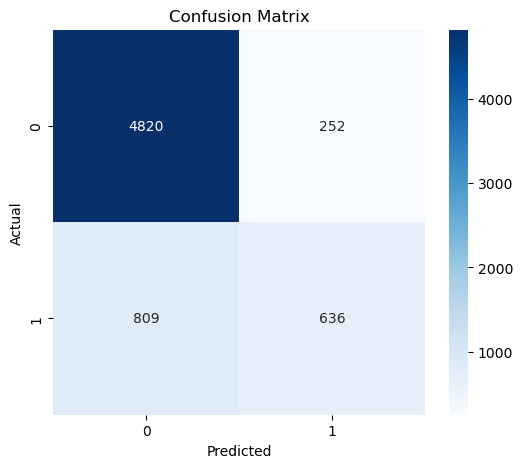

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

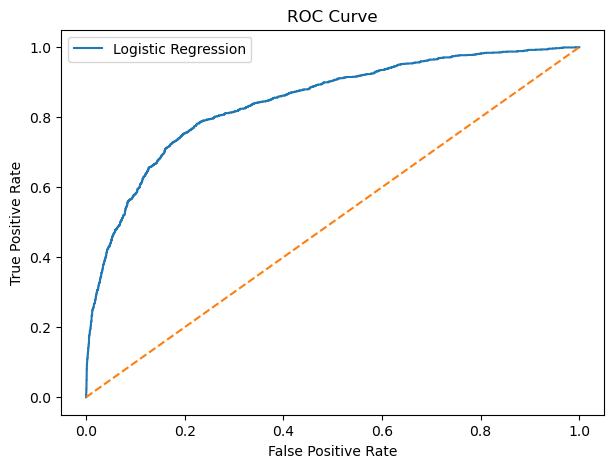

ROC AUC Score : 0.8433564286727866


In [16]:
# ROC Curve
y_prob = lr_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("ROC AUC Score :", roc_auc_score(y_test, y_prob))

In [17]:
# CatBoost Model
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test)

cat_prob = cat_model.predict_proba(X_test)[:,1]

In [18]:
# CatBoost Evaluation
print("Accuracy :", accuracy_score(y_test, cat_pred))

print("\nClassification Report\n")

print(classification_report(y_test, cat_pred))

Accuracy : 0.9338652754334816

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5072
           1       0.97      0.72      0.83      1445

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



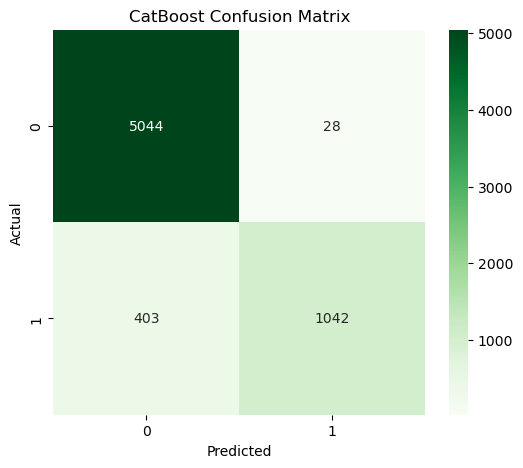

In [19]:
# CatBoost Confusion Matrix
cm = confusion_matrix(y_test, cat_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("CatBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

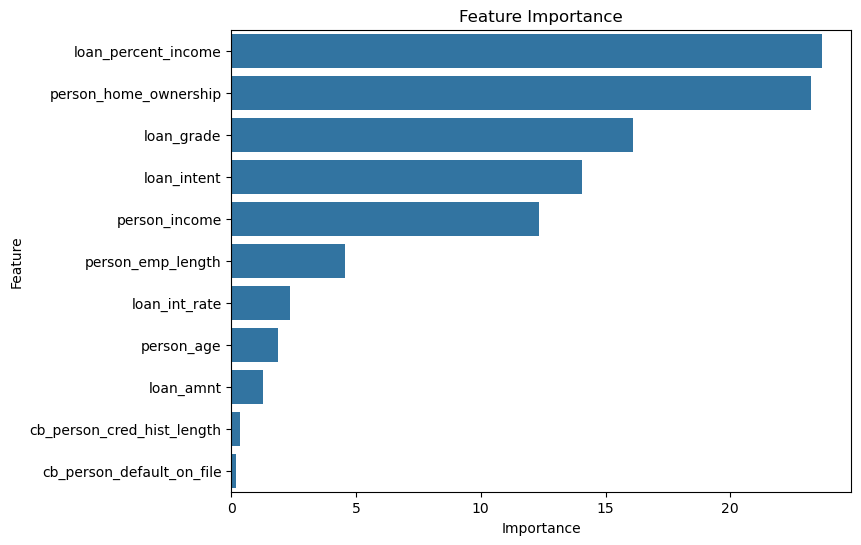

,Feature,Importance
8,loan_percent_income,23.666610
2,person_home_ownership,23.222269
5,loan_grade,16.099028
4,loan_intent,14.056313
1,person_income,12.328673
3,person_emp_length,4.576176
7,loan_int_rate,2.352250
0,person_age,1.875097
6,loan_amnt,1.285041
10,cb_person_cred_hist_length,0.364730


In [20]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

importance.head(10)

In [21]:
# Business Cost Definition
FP_COST = 1000     # False Positive Cost
FN_COST = 5000     # False Negative Cost

In [22]:
# Threshold Optimization
thresholds = np.arange(0.1, 1.0, 0.05)

costs = []

for t in thresholds:

    pred = (cat_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    total_cost = (fp * FP_COST) + (fn * FN_COST)

    costs.append(total_cost)

In [23]:
# Best Threshold
best_index = np.argmin(costs)

best_threshold = thresholds[best_index]

print("Best Threshold :", best_threshold)

print("Minimum Business Cost :", costs[best_index])

Best Threshold : 0.15000000000000002
Minimum Business Cost : 1635000


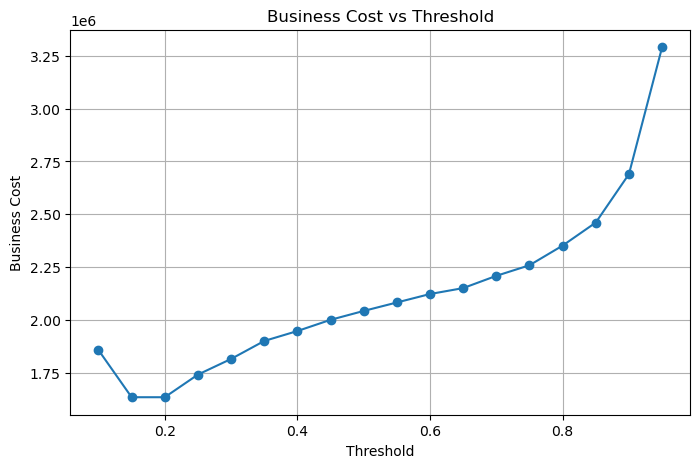

In [24]:
# Business Cost vs Threshold
plt.figure(figsize=(8,5))

plt.plot(thresholds, costs, marker="o")

plt.xlabel("Threshold")

plt.ylabel("Business Cost")

plt.title("Business Cost vs Threshold")

plt.grid(True)

plt.show()

In [25]:
# Final Prediction
final_pred = (cat_prob >= best_threshold).astype(int)

print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92      5072
           1       0.68      0.85      0.76      1445

    accuracy                           0.88      6517
   macro avg       0.82      0.87      0.84      6517
weighted avg       0.89      0.88      0.88      6517



Conclusion

This project predicted loan default risk using Logistic Regression and CatBoost classification models. The dataset was cleaned, preprocessed, and categorical features were encoded before model training. Business costs were assigned to false positives and false negatives, and different decision thresholds were evaluated to minimize the total business cost. CatBoost provided strong predictive performance, while threshold optimization helped reduce financial risk by selecting the most cost-effective decision boundary. Feature importance analysis also identified the most influential variables affecting loan default prediction.